In [1]:
file_path <- "../../results/S5/unique_methods_protein_features_added.txt"
out_plot_1 <- "../../figures/GRAVY_by_enrich.pdf"
out_plot_1_1 <- "../../figures/GRAVY_by_enrich.mean_CI.pdf"
out_plot_2 <- "../../figures/pI_by_enrich.pdf"

In [6]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

fread_c(file_path) -> df
head(df)
colnames(df)

df  %>% filter(Supported_Enrichments!='C8, MWCO, No_enrichment, PAGE, PCP') -> df

,Protein,Seq,Supported_Enrichments,isoelectric_point,gravy,charge_pH7
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,MPSHIRKSQARRGRRRRGLPGVSNCGTGGSPWEVVLAPRRGEWSGVRTASQAQVVSLPWMPVGVGTAEPRTLPGDHSQATFPTLPSCSRRQRRPGRSAHRLLVSAALRSGSSALPF,No_enrichment,11.999968,-0.55086207,14.7504484
2,PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,MSKAPWAAGLWMRRRKPHPLHHPLTRKDTDSFGEGCPVSAGALGRWPWDTVPVPVCVHHV,No_enrichment,9.837182,-0.43500000,3.9195494
3,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,MAVGGAGDVDQSLQQPHQQSI,PCP,4.196048,-0.47142857,-2.4102296
4,PB.1001.12:chr1:-|8|2625:155:2039|canonical|ATG,MDDWKPSPLIKPFGARKKRSWYLTWKYKLTNQRALRRFCQTGAVLFLLVTVIVNIKLILDTRRAISEANEDPEPEQDYDEALGRLEPPRRRGSGPRRVLDVEVYSSRSKVYVAVDGTTVLEDEAREQGRGIHVIVLNQATGHVMAKRVFDTYSPHEDEAMVLFLNMVAPGRVLICTVKDEGSFHLKDTAKALLRSLGSQAGPALGWRDTWAFVGRKGEAECHWADTELNRRRRRFCSKVEGYGSVCSCKDPTPIEFSPDPLPDNKVLNVPVAVIAGNRPNYLYRMLRSLLSAQGVSPQMITVFIDGYYEEPMDVVALFGLRGIQHTPISIKNARVSQHYKASLTATFNLFPEAKFAVVLEEDLDIAVDFFSFLSQSIHLLEEDDSLYCISAWNDQGYEHTAEDPALLYRVETMPGLGWVLRRSLYKEELEPKWPTPEKLWDWDMWMRMPEQRRGRECIIPDVSRSYHFGIVGLNMNGYFHEAYFKKHKFNTVPGVQLRNVDSLKKEAYEVEVHRLLSEAEVLDHSKNPCEDSFLPDTEGHTYVAFIRMEKDDDFTTWTQLAKCLHIWDLDVRGNHRGLWRLFRKKNHFLVVGVPASPYSVKKPPSVTPIFLEPPPKEEGAPGAPEQT,No_enrichment,6.441074,-0.40478469,-3.9111215
5,PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,MSYRCLAGQQVGVGQTM,C8,7.975271,0.07647059,0.4894447
6,PB.10020.13:chr12:+|22|1011:465:531|noncoding|ATG,MIADFIIKQFICIFWSLTLIL,PCP,5.585193,1.89047619,-0.5094245


[1] "Protein"               "Seq"                   "Supported_Enrichments"
[4] "isoelectric_point"     "gravy"                 "charge_pH7"

In [7]:
head(df)

,Protein,Seq,Supported_Enrichments,isoelectric_point,gravy,charge_pH7
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,MPSHIRKSQARRGRRRRGLPGVSNCGTGGSPWEVVLAPRRGEWSGVRTASQAQVVSLPWMPVGVGTAEPRTLPGDHSQATFPTLPSCSRRQRRPGRSAHRLLVSAALRSGSSALPF,No_enrichment,11.999968,-0.55086207,14.7504484
2,PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,MSKAPWAAGLWMRRRKPHPLHHPLTRKDTDSFGEGCPVSAGALGRWPWDTVPVPVCVHHV,No_enrichment,9.837182,-0.43500000,3.9195494
3,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,MAVGGAGDVDQSLQQPHQQSI,PCP,4.196048,-0.47142857,-2.4102296
4,PB.1001.12:chr1:-|8|2625:155:2039|canonical|ATG,MDDWKPSPLIKPFGARKKRSWYLTWKYKLTNQRALRRFCQTGAVLFLLVTVIVNIKLILDTRRAISEANEDPEPEQDYDEALGRLEPPRRRGSGPRRVLDVEVYSSRSKVYVAVDGTTVLEDEAREQGRGIHVIVLNQATGHVMAKRVFDTYSPHEDEAMVLFLNMVAPGRVLICTVKDEGSFHLKDTAKALLRSLGSQAGPALGWRDTWAFVGRKGEAECHWADTELNRRRRRFCSKVEGYGSVCSCKDPTPIEFSPDPLPDNKVLNVPVAVIAGNRPNYLYRMLRSLLSAQGVSPQMITVFIDGYYEEPMDVVALFGLRGIQHTPISIKNARVSQHYKASLTATFNLFPEAKFAVVLEEDLDIAVDFFSFLSQSIHLLEEDDSLYCISAWNDQGYEHTAEDPALLYRVETMPGLGWVLRRSLYKEELEPKWPTPEKLWDWDMWMRMPEQRRGRECIIPDVSRSYHFGIVGLNMNGYFHEAYFKKHKFNTVPGVQLRNVDSLKKEAYEVEVHRLLSEAEVLDHSKNPCEDSFLPDTEGHTYVAFIRMEKDDDFTTWTQLAKCLHIWDLDVRGNHRGLWRLFRKKNHFLVVGVPASPYSVKKPPSVTPIFLEPPPKEEGAPGAPEQT,No_enrichment,6.441074,-0.40478469,-3.9111215
5,PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,MSYRCLAGQQVGVGQTM,C8,7.975271,0.07647059,0.4894447
6,PB.10020.13:chr12:+|22|1011:465:531|noncoding|ATG,MIADFIIKQFICIFWSLTLIL,PCP,5.585193,1.89047619,-0.5094245


In [8]:
nrow(df)
# df %>% filter(nchar(Seq)<=150) %>% nrow()
# df %>% filter(nchar(Seq)<=150) -> df
nrow(df)

[1] 16703

[1] 16703

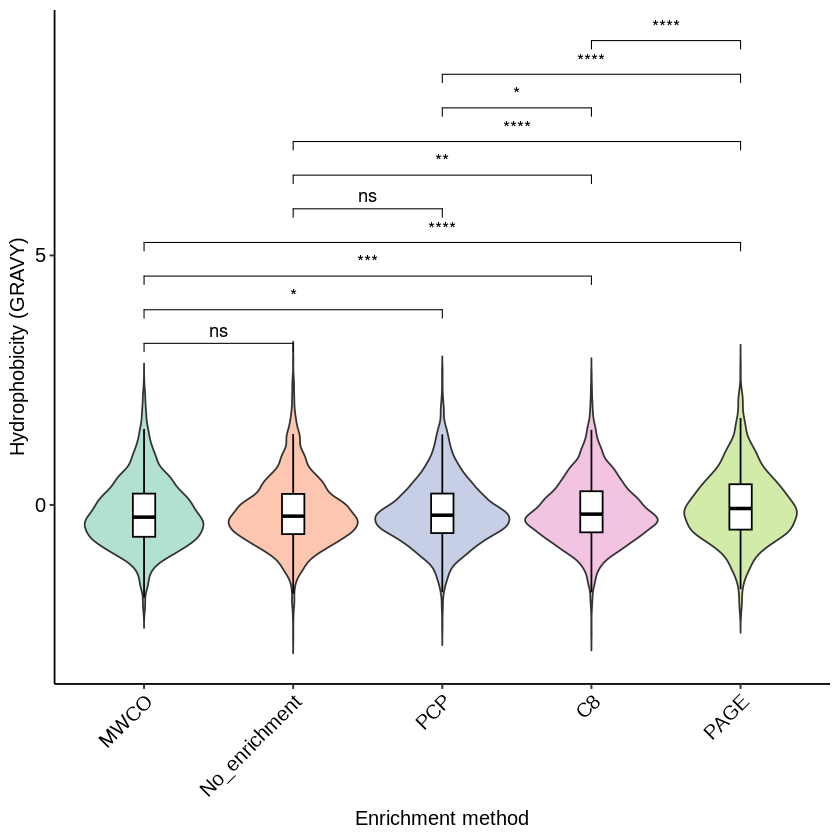

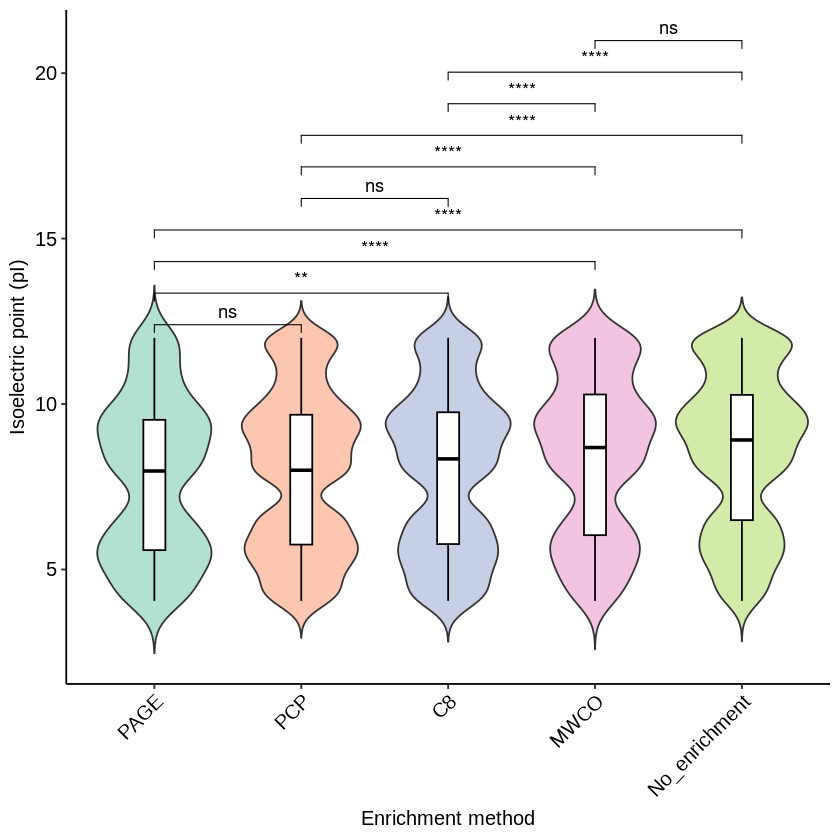

In [19]:
# 1) 计算中位数顺序（从小到大）
ord <- df %>%
  group_by(Supported_Enrichments) %>%
  summarise(med = median(gravy, na.rm = TRUE), .groups = "drop") %>%
  arrange(med) %>%
  pull(Supported_Enrichments)

# 2) 应用到因子水平（x 轴顺序 = 中位数从小到大）
df <- df %>%
  mutate(Supported_Enrichments = factor(Supported_Enrichments, levels = ord))
ggplot(df, aes(x = Supported_Enrichments, y = gravy, fill = Supported_Enrichments)) +
  # 小提琴图（分布）
  geom_violin(trim = FALSE, alpha = 0.5) +
  
  # 叠加盒形图（透明填充，仅中间显示）
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA, color = "black") +

  # 美化主题与标签
  labs(
       x = "Enrichment method",
       y = "Hydrophobicity (GRAVY)") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
stat_compare_means(
    comparisons = combn(levels(df$Supported_Enrichments), 2, simplify = FALSE),
    method = "wilcox.test",
    label = "p.signif"
  ) +
  scale_fill_manual(values = brewer.pal(length(unique(df$Supported_Enrichments)), "Set2")) ->p1

p1

ggsave(p1,filename = out_plot_1,height = 5,width = 5)

library(dplyr)
library(ggpubr)
library(RColorBrewer)
df -> df_1
df_1$Supported_Enrichments <- reorder(df_1$Supported_Enrichments, df_1$isoelectric_point, median)
# 1) 计算中位数顺序（从小到大）
ord <- df_1 %>%
  group_by(Supported_Enrichments) %>%
  summarise(med = median(isoelectric_point, na.rm = TRUE), .groups = "drop") %>%
  arrange(med) %>%
  pull(Supported_Enrichments)

# 2) 应用到因子水平（x 轴顺序 = 中位数从小到大）
df_1 <- df_1 %>%
  mutate(Supported_Enrichments = factor(Supported_Enrichments, levels = ord))

# 3) 颜色数量自适应（Set2 最多8色，超出则插值扩展）
n_grp <- length(ord)
pal   <- colorRampPalette(brewer.pal(min(8, max(3, n_grp)), "Set2"))(n_grp)

# 4) 重新绘图
p2 <- ggplot(df_1, aes(x = Supported_Enrichments, y = isoelectric_point, fill = Supported_Enrichments)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.15, fill = "white", outlier.shape = NA, color = "black") +
  labs(x = "Enrichment method", y = "Isoelectric point (pI)") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
  stat_compare_means(
    comparisons = combn(levels(df_1$Supported_Enrichments), 2, simplify = FALSE),
    method = "wilcox.test",
    label = "p.signif"
  ) +
  scale_fill_manual(values = pal)
p2
ggsave(p2,filename = out_plot_2,height = 5,width = 5)

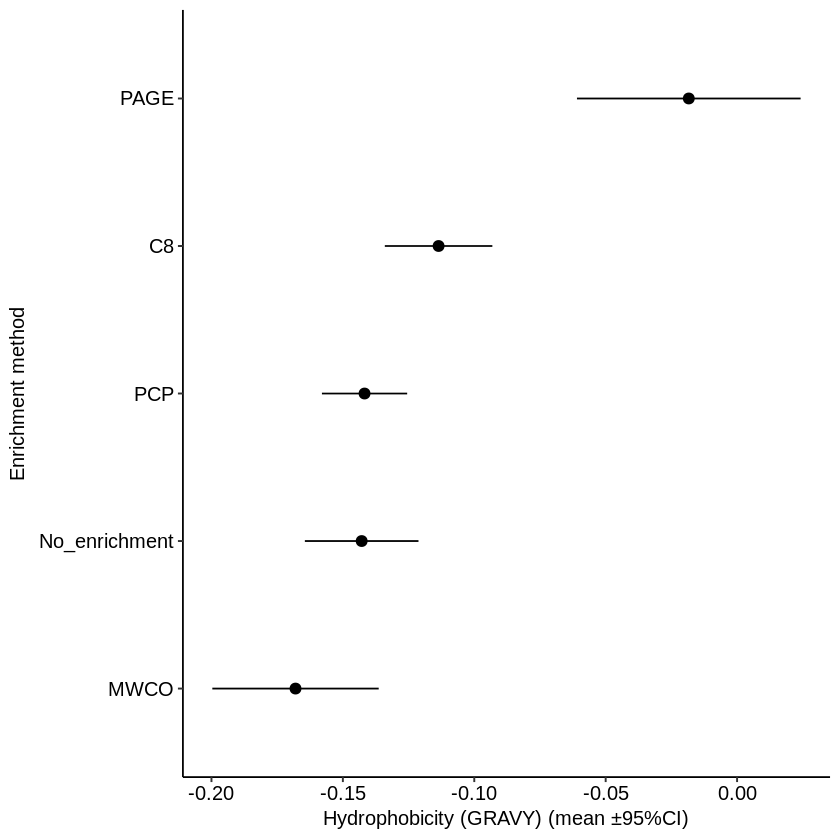

In [16]:
library(dplyr)
df_mean <- df %>%
  group_by(Supported_Enrichments) %>%
  summarise(mean = mean(gravy, na.rm=TRUE),
            se = sd(gravy, na.rm=TRUE)/sqrt(n()),
            .groups="drop")

ggplot(df_mean, aes(reorder(Supported_Enrichments, mean), mean)) +
  geom_pointrange(aes(ymin = mean - 1.96*se, ymax = mean + 1.96*se)) +
  coord_flip() + labs(x = "Enrichment method", y = "Hydrophobicity (GRAVY) (mean ±95%CI)") + theme_3() -> p1_supple
p1_supple
ggsave(p1_supple,filename = out_plot_1_1,height = 5,width = 5)

In [10]:
df[is.na(df$isoelectric_point),]
df[is.na(df$gravy),]

Protein,Seq,Supported_Enrichments,isoelectric_point,gravy,charge_pH7
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>


Protein,Seq,Supported_Enrichments,isoelectric_point,gravy,charge_pH7
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>


In [11]:
df %>% na.omit() -> df_1
df_1 %>% dplyr::group_by(Supported_Enrichments) %>% dplyr::summarise(median_pI=median(isoelectric_point))
df_1 %>% group_by(Supported_Enrichments) %>% summarise(median_gravy=median(gravy))

Supported_Enrichments,median_pI
<chr>,<dbl>
C8,8.342805
MWCO,8.685455
No_enrichment,8.914253
PAGE,7.976851
PCP,7.999833


Supported_Enrichments,median_gravy
<chr>,<dbl>
C8,-0.18507130
MWCO,-0.24545455
No_enrichment,-0.22553191
PAGE,-0.07220587
PCP,-0.20689655
